# Dataset Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from keras.models import Sequential
from keras.layers import Conv2D, Dropout, BatchNormalization, Flatten, Dense, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from tensorflow.keras.metrics import RootMeanSquaredError

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

2026-06-30 16:25:21.953371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782836722.140359      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782836722.194010      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782836722.643219      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782836722.643263      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782836722.643266      58 computation_placer.cc:177] computation placer alr

In [4]:
df = pd.read_csv("/kaggle/input/datasets/milanzdravkovic/pharma-sales-data/salesweekly.csv")

# Check Dataset

In [6]:
df.head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,1/12/2014,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,1/19/2014,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,1/26/2014,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2/2/2014,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [7]:
df.shape


(302, 9)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   302 non-null    object 
 1   M01AB   302 non-null    float64
 2   M01AE   302 non-null    float64
 3   N02BA   302 non-null    float64
 4   N02BE   302 non-null    float64
 5   N05B    302 non-null    float64
 6   N05C    302 non-null    float64
 7   R03     302 non-null    float64
 8   R06     302 non-null    float64
dtypes: float64(8), object(1)
memory usage: 21.4+ KB


In [9]:
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,35.102441,27.167611,27.060295,208.627161,61.740853,4.138935,38.439811,20.224561
std,8.617106,7.043491,8.086458,76.069221,22.436970,3.129265,22.900873,11.381464
min,7.670000,6.237000,3.500000,86.250000,18.000000,0.000000,2.000000,1.000000
25%,29.387500,22.387500,21.300000,149.300000,47.000000,2.000000,21.000000,11.475000
50%,34.565000,26.789500,26.500000,198.300000,57.000000,3.979167,35.000000,17.500000
75%,40.175000,31.046500,32.475000,252.471500,71.000000,6.000000,51.000000,26.000000
max,65.330000,53.571000,60.125000,546.899000,154.000000,17.000000,131.000000,65.000000


# Missing Values

In [10]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


# Date Conversion

In [11]:
df['datum'] = pd.to_datetime(df['datum'])

# Select Required Categories

In [13]:
categories = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

sales_df = df[['datum'] + categories].copy()

sales_df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [14]:
categories = [
    'M01AB','M01AE','N02BA','N02BE',
    'N05B','N05C','R03','R06'
]

sales_df = df[['datum'] + categories].copy()
sales_df['datum'] = pd.to_datetime(sales_df['datum'])

# EDA

## Weekly Sales Trend

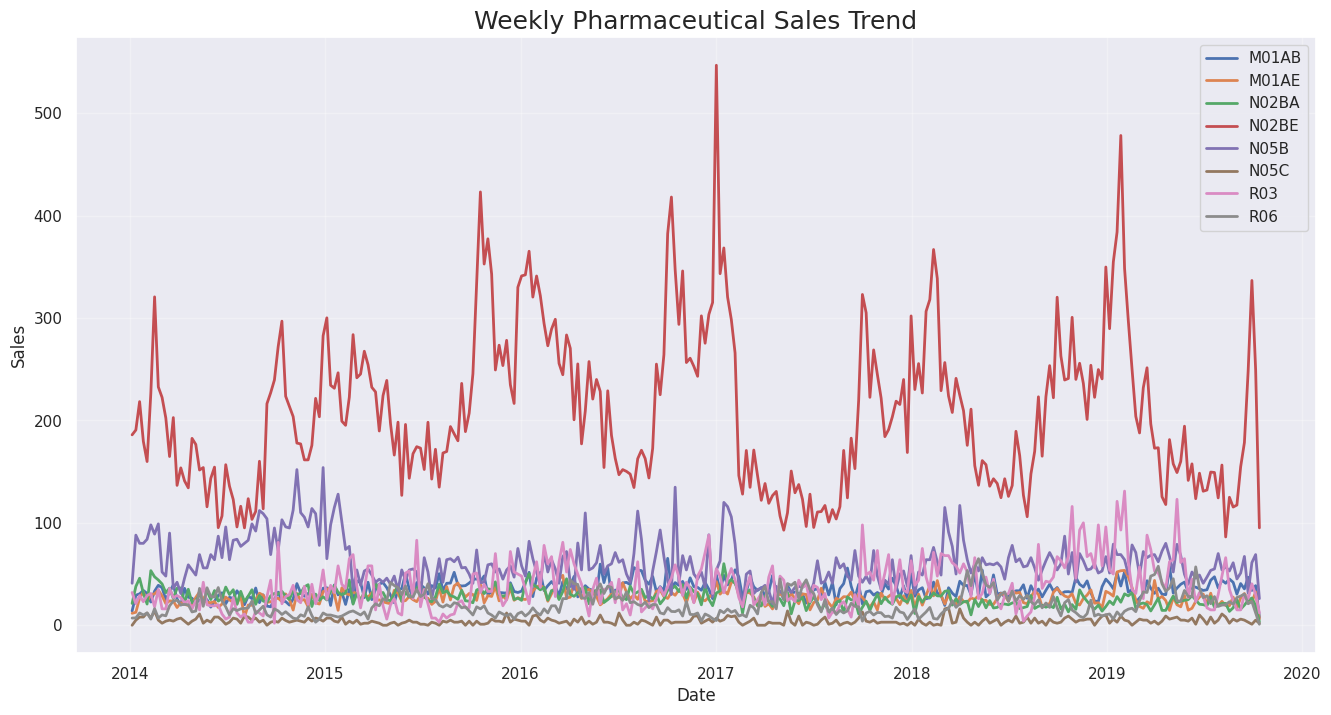

In [15]:
plt.figure(figsize=(16,8))

for col in categories:
    plt.plot(sales_df['datum'], sales_df[col], linewidth=2, label=col)

plt.title("Weekly Pharmaceutical Sales Trend", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Correlation Heatmap

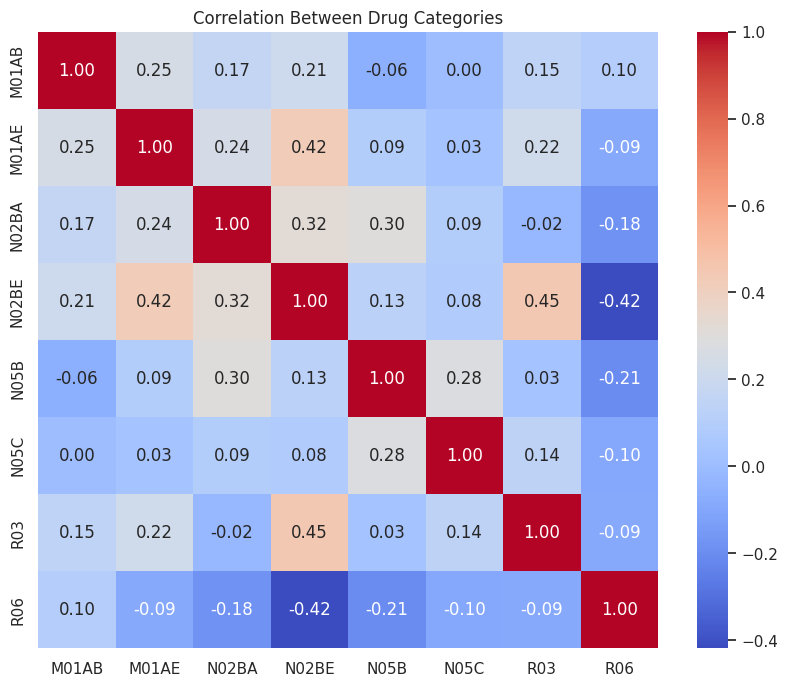

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    sales_df[categories].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Between Drug Categories")
plt.show()

## Average Sales Comparison

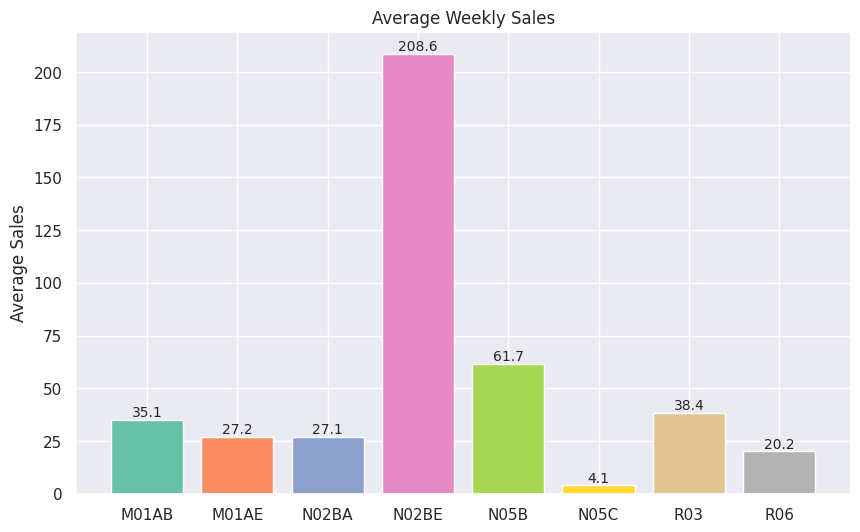

In [17]:
avg_sales = sales_df[categories].mean()

colors = plt.cm.Set2.colors

plt.figure(figsize=(10,6))

bars = plt.bar(avg_sales.index, avg_sales.values, color=colors)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h,
        f'{h:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Average Weekly Sales")
plt.ylabel("Average Sales")
plt.show()

## Sales Distribution

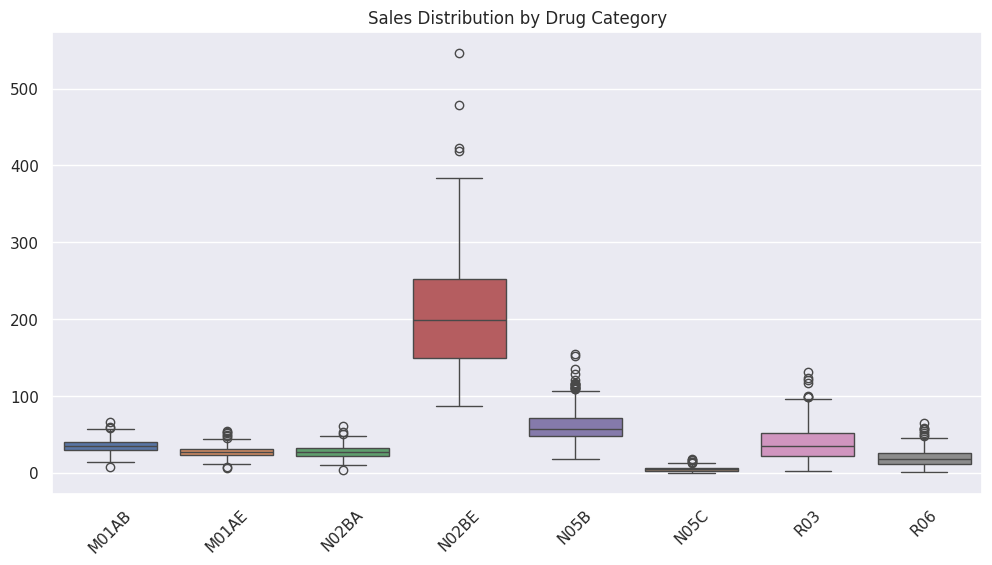

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(data=sales_df[categories])

plt.title("Sales Distribution by Drug Category")
plt.xticks(rotation=45)
plt.show()

## Monthly Sales Trend

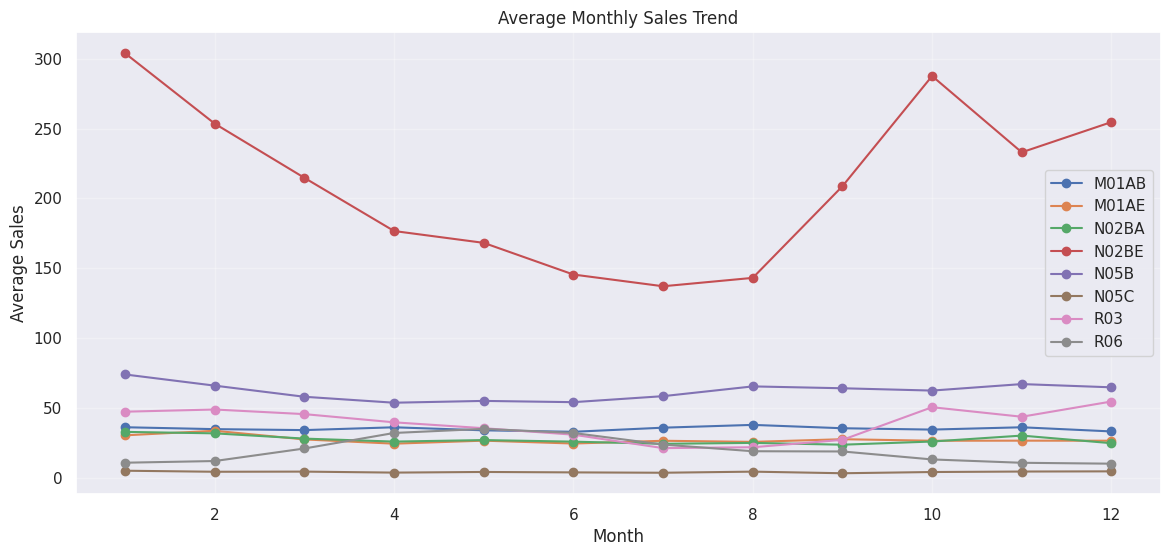

In [19]:
monthly = sales_df.copy()

monthly['Month'] = monthly['datum'].dt.month

monthly_avg = monthly.groupby('Month')[categories].mean()

monthly_avg.plot(
    figsize=(14,6),
    marker='o'
)

plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(alpha=0.3)
plt.show()

# Preprocessing

In [20]:
sales_df['Year'] = sales_df['datum'].dt.year
sales_df['Month'] = sales_df['datum'].dt.month
sales_df['Week'] = sales_df['datum'].dt.isocalendar().week.astype(int)
sales_df['Quarter'] = sales_df['datum'].dt.quarter

In [21]:
sales_df = sales_df.drop('datum', axis=1)

sales_df.head()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Week,Quarter
0,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0,2014,1,1,1
1,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2,2014,1,2,1
2,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0,2014,1,3,1
3,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0,2014,1,4,1
4,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0,2014,2,5,1


In [22]:
print(sales_df.isnull().sum())

M01AB      0
M01AE      0
N02BA      0
N02BE      0
N05B       0
N05C       0
R03        0
R06        0
Year       0
Month      0
Week       0
Quarter    0
dtype: int64


In [23]:
sales_df.fillna(sales_df.mean(), inplace=True)

In [24]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   M01AB    302 non-null    float64
 1   M01AE    302 non-null    float64
 2   N02BA    302 non-null    float64
 3   N02BE    302 non-null    float64
 4   N05B     302 non-null    float64
 5   N05C     302 non-null    float64
 6   R03      302 non-null    float64
 7   R06      302 non-null    float64
 8   Year     302 non-null    int32  
 9   Month    302 non-null    int32  
 10  Week     302 non-null    int64  
 11  Quarter  302 non-null    int32  
dtypes: float64(8), int32(3), int64(1)
memory usage: 24.9 KB


In [25]:
targets = [
    'M01AB','M01AE','N02BA','N02BE',
    'N05B','N05C','R03','R06'
]

features = ['Year','Month','Week','Quarter']

In [26]:
from sklearn.model_selection import train_test_split

datasets = {}

for target in targets:

    X = sales_df[features]
    y = sales_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    datasets[target] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

print("Data preprocessing completed.")

Data preprocessing completed.


In [27]:
from sklearn.preprocessing import StandardScaler

scalers = {}

for target in targets:

    scaler = StandardScaler()

    X_train = scaler.fit_transform(datasets[target]['X_train'])
    X_test = scaler.transform(datasets[target]['X_test'])

    datasets[target]['X_train'] = X_train
    datasets[target]['X_test'] = X_test

    scalers[target] = scaler

print("Feature scaling completed.")

Feature scaling completed.


# Model Train 

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_results = []

for target in targets:

    X_train = datasets[target]['X_train']
    X_test = datasets[target]['X_test']

    y_train = datasets[target]['y_train']
    y_test = datasets[target]['y_test']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    lr_results.append([target, mae, rmse, r2])

    print("="*60)
    print(f"Target : {target}")
    print("="*60)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

Target : M01AB
MAE  : 7.1510
RMSE : 8.8141
R2   : -0.1505
Target : M01AE
MAE  : 4.7921
RMSE : 6.2186
R2   : -0.3330
Target : N02BA
MAE  : 5.3309
RMSE : 6.6557
R2   : 0.2615
Target : N02BE
MAE  : 51.0751
RMSE : 62.4586
R2   : -0.0427
Target : N05B
MAE  : 15.1642
RMSE : 18.1464
R2   : 0.0703
Target : N05C
MAE  : 2.2534
RMSE : 2.8954
R2   : -0.0553
Target : R03
MAE  : 17.0240
RMSE : 21.9029
R2   : 0.0623
Target : R06
MAE  : 8.6521
RMSE : 11.3327
R2   : 0.1377


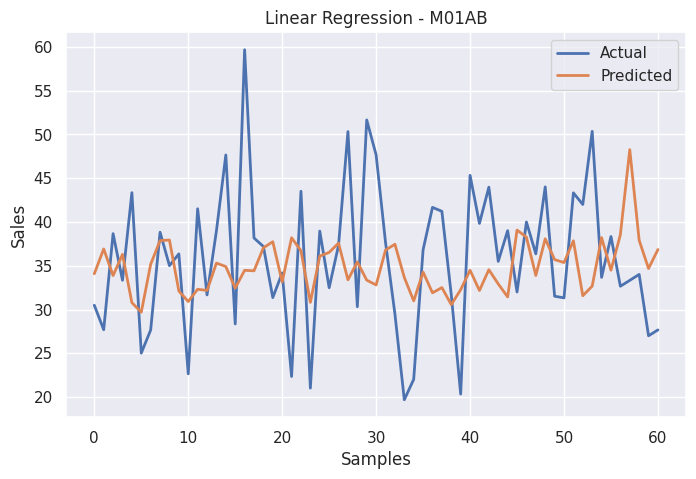

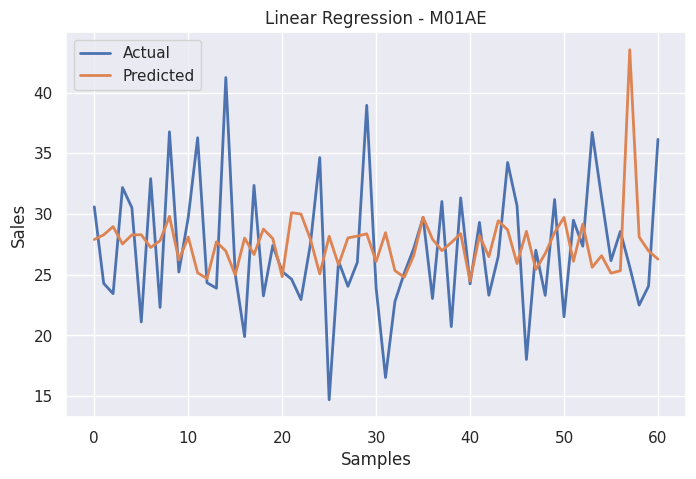

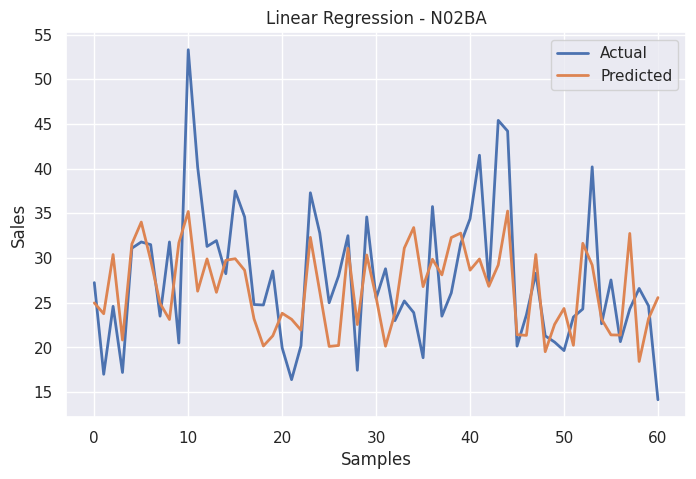

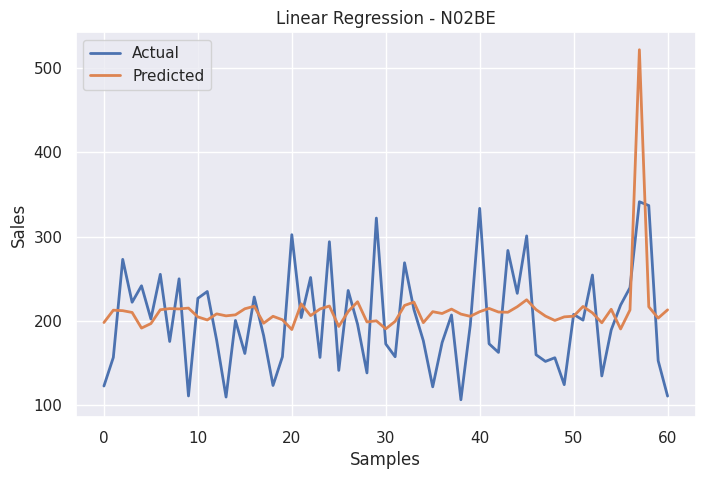

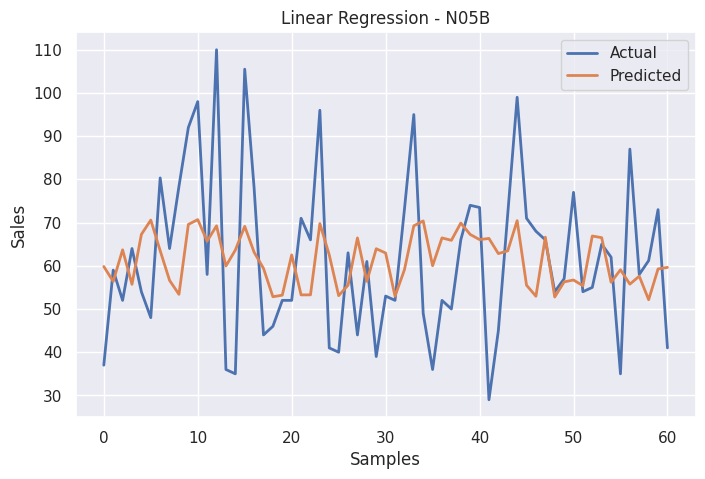

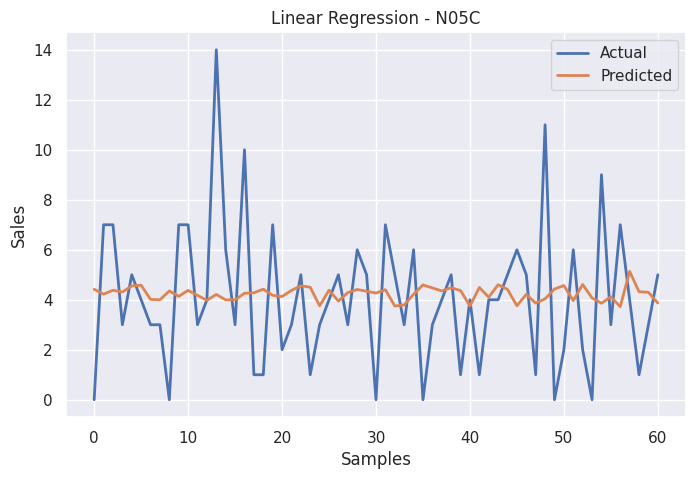

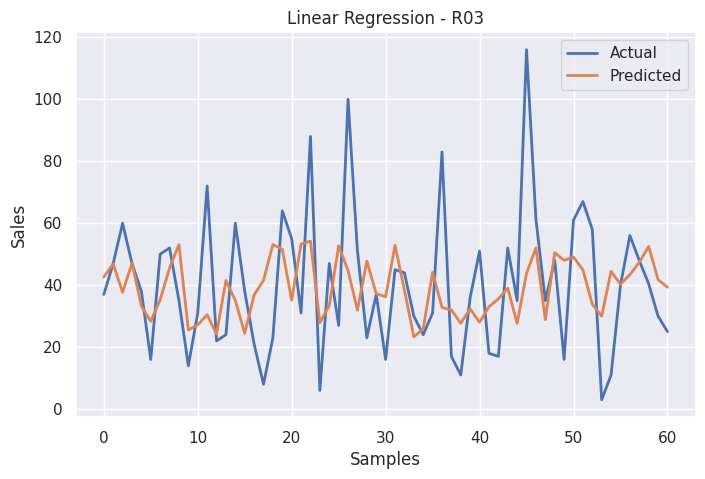

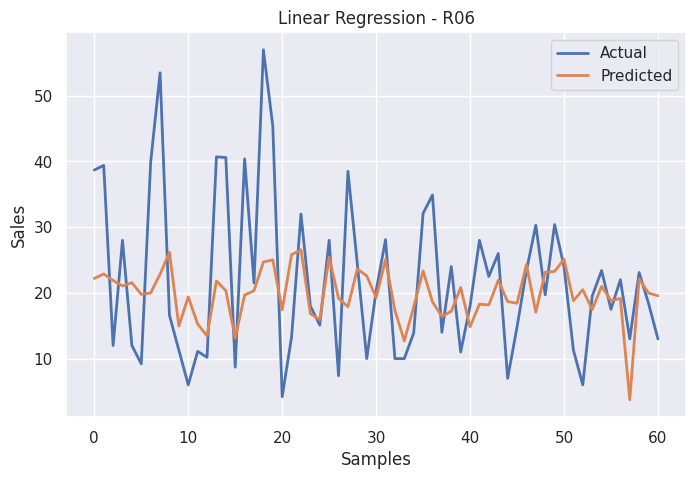

In [29]:
import matplotlib.pyplot as plt

for target in targets:

    X_test = datasets[target]['X_test']
    y_test = datasets[target]['y_test']

    model = LinearRegression()
    model.fit(
        datasets[target]['X_train'],
        datasets[target]['y_train']
    )

    pred = model.predict(X_test)

    plt.figure(figsize=(8,5))

    plt.plot(
        y_test.values,
        label='Actual',
        linewidth=2
    )

    plt.plot(
        pred,
        label='Predicted',
        linewidth=2
    )

    plt.title(f'Linear Regression - {target}')
    plt.xlabel("Samples")
    plt.ylabel("Sales")

    plt.legend()
    plt.grid(True)

    plt.show()

In [30]:
lr_df = pd.DataFrame(
    lr_results,
    columns=['Target','MAE','RMSE','R2']
)

lr_df

,Target,MAE,RMSE,R2
0,M01AB,7.150956,8.814120,-0.150483
1,M01AE,4.792076,6.218639,-0.332957
2,N02BA,5.330888,6.655739,0.261532
3,N02BE,51.075079,62.458571,-0.042711
4,N05B,15.164218,18.146405,0.070334
5,N05C,2.253429,2.895445,-0.055324
6,R03,17.024000,21.902932,0.062289
7,R06,8.652062,11.332745,0.137676


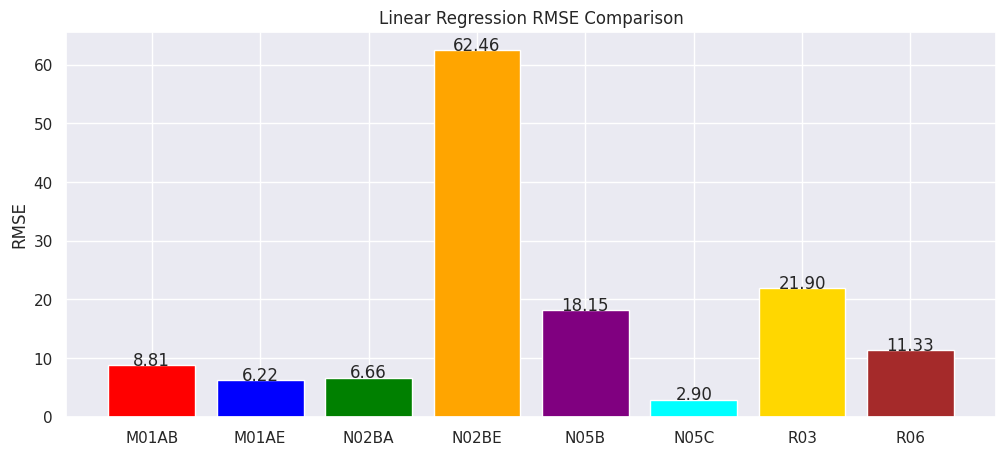

In [31]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    lr_df['Target'],
    lr_df['RMSE'],
    color=['red','blue','green','orange',
           'purple','cyan','gold','brown']
)

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        f'{y:.2f}',
        ha='center'
    )

plt.title("Linear Regression RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

# Random Forest Model

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_results = []

for target in targets:

    X_train = datasets[target]['X_train']
    X_test = datasets[target]['X_test']

    y_train = datasets[target]['y_train']
    y_test = datasets[target]['y_test']

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    rf_results.append([target, mae, rmse, r2])

    print("="*60)
    print(f"Random Forest - {target}")
    print("="*60)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

Random Forest - M01AB
MAE  : 6.3555
RMSE : 7.7748
R²   : 0.1048
Random Forest - M01AE
MAE  : 4.9413
RMSE : 6.4202
R²   : -0.4208
Random Forest - N02BA
MAE  : 5.5659
RMSE : 6.8461
R²   : 0.2187
Random Forest - N02BE
MAE  : 27.3809
RMSE : 36.6848
R²   : 0.6403
Random Forest - N05B
MAE  : 12.1432
RMSE : 15.4370
R²   : 0.3272
Random Forest - N05C
MAE  : 2.5898
RMSE : 3.3440
R²   : -0.4076
Random Forest - R03
MAE  : 12.7165
RMSE : 17.7415
R²   : 0.3848
Random Forest - R06
MAE  : 5.9282
RMSE : 7.6856
R²   : 0.6034


# Evaluation Graph

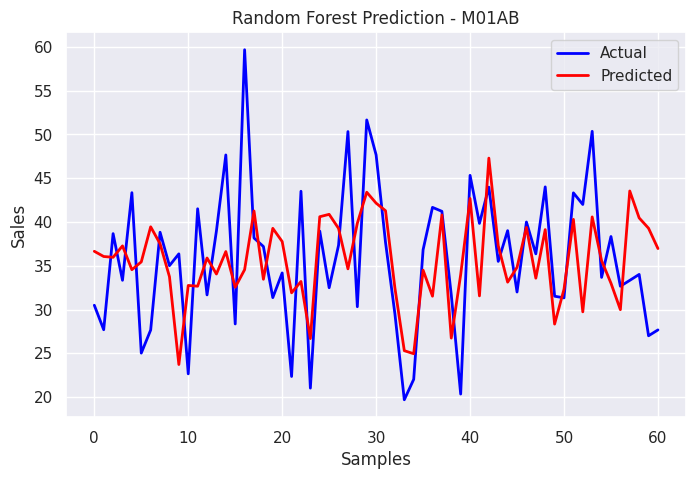

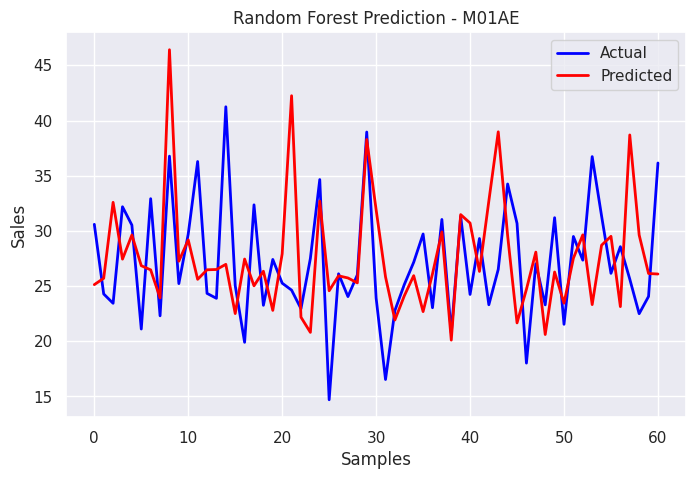

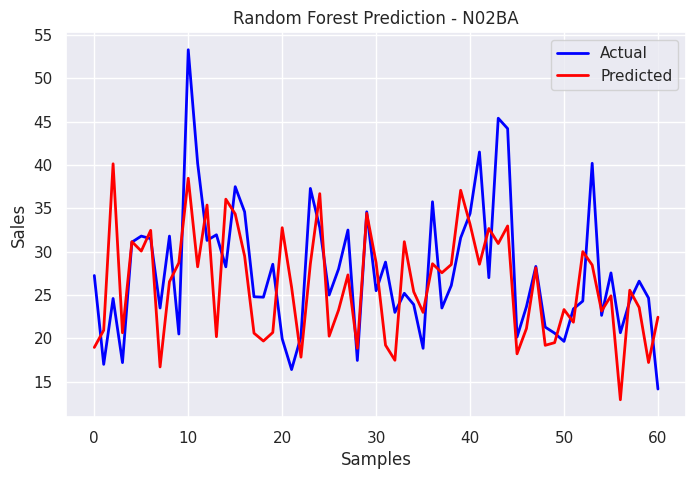

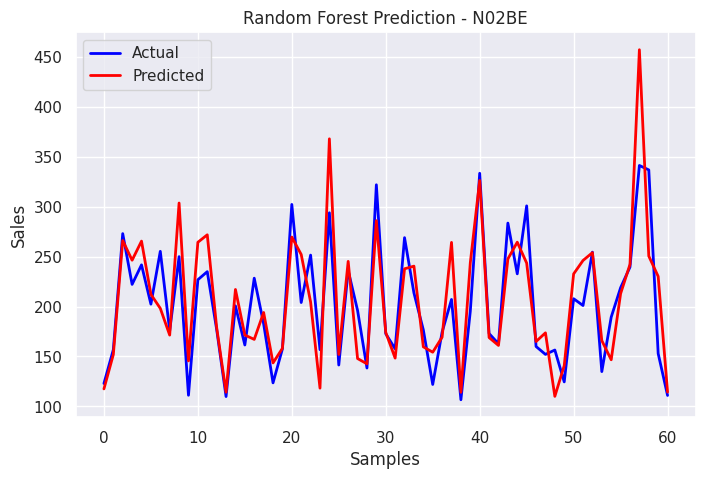

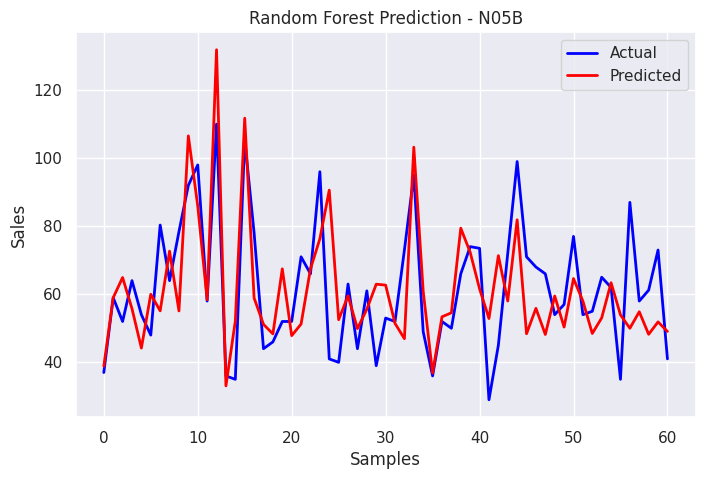

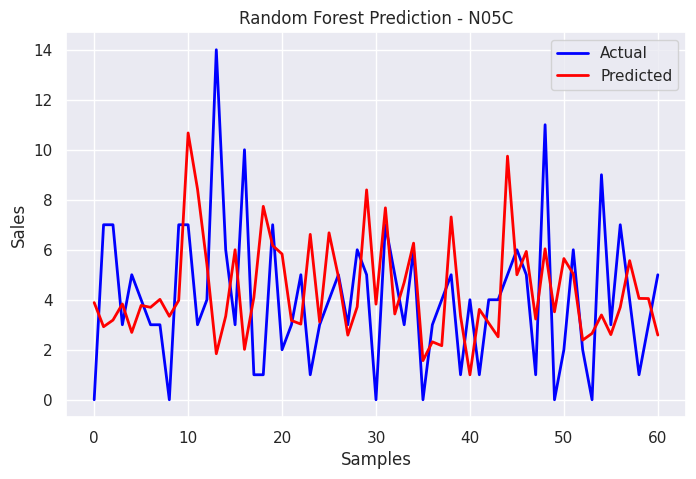

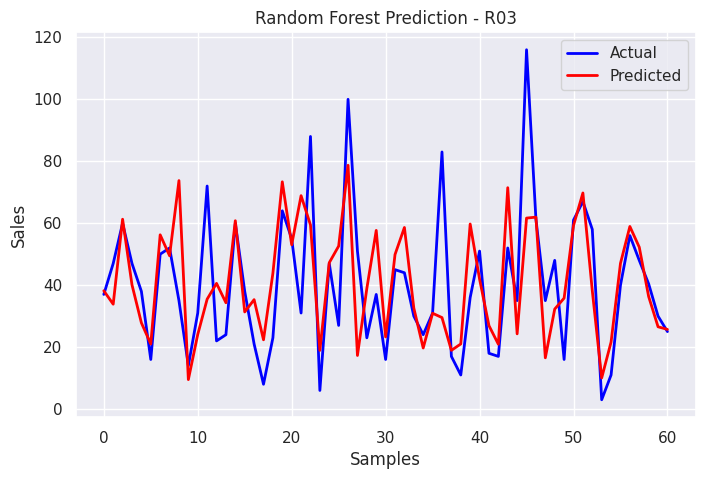

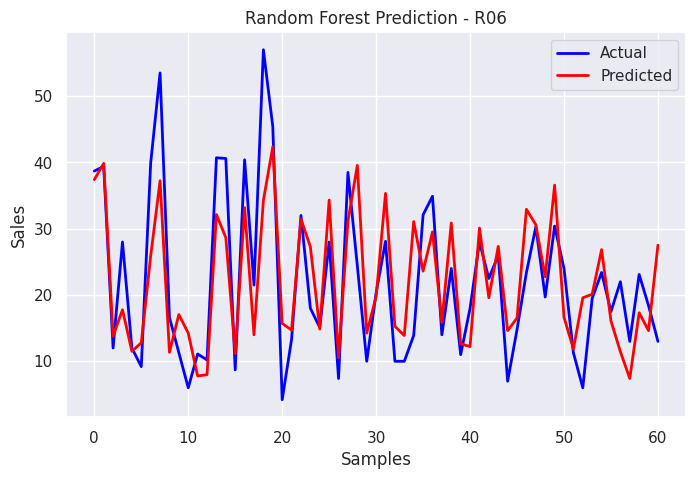

In [33]:
import matplotlib.pyplot as plt

for target in targets:

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10
    )

    model.fit(
        datasets[target]['X_train'],
        datasets[target]['y_train']
    )

    pred = model.predict(datasets[target]['X_test'])

    plt.figure(figsize=(8,5))

    plt.plot(
        datasets[target]['y_test'].values,
        color='blue',
        label='Actual',
        linewidth=2
    )

    plt.plot(
        pred,
        color='red',
        label='Predicted',
        linewidth=2
    )

    plt.title(f'Random Forest Prediction - {target}')

    plt.xlabel("Samples")
    plt.ylabel("Sales")

    plt.legend()

    plt.grid(True)

    plt.show()

In [34]:
rf_df = pd.DataFrame(
    rf_results,
    columns=[
        'Target',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

rf_df

,Target,MAE,RMSE,R2 Score
0,M01AB,6.355458,7.774829,0.104834
1,M01AE,4.941294,6.420187,-0.420760
2,N02BA,5.565897,6.846091,0.218688
3,N02BE,27.380857,36.684825,0.640290
4,N05B,12.143194,15.436984,0.327224
5,N05C,2.589794,3.344016,-0.407641
6,R03,12.716500,17.741500,0.384759
7,R06,5.928203,7.685565,0.603401


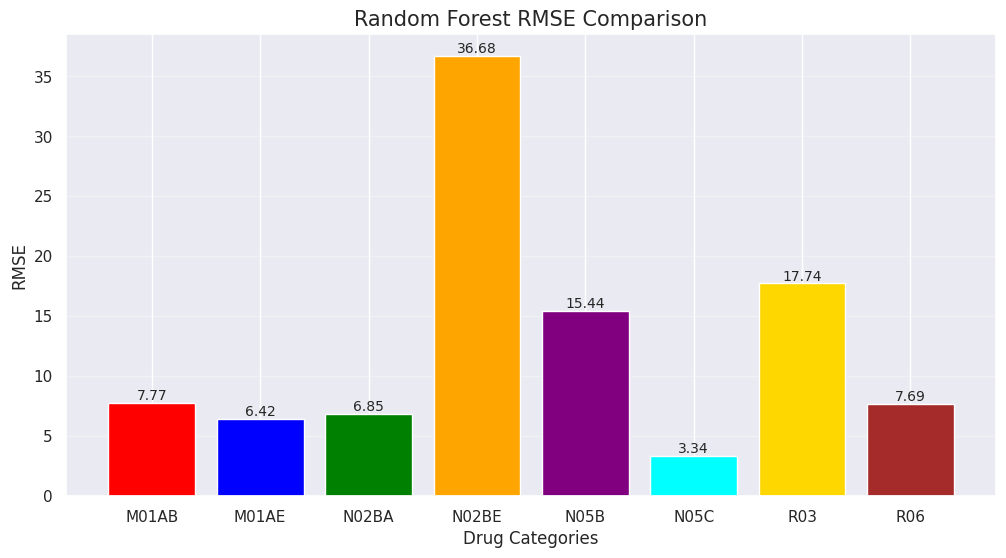

In [35]:
plt.figure(figsize=(12,6))

colors = [
    'red',
    'blue',
    'green',
    'orange',
    'purple',
    'cyan',
    'gold',
    'brown'
]

bars = plt.bar(
    rf_df['Target'],
    rf_df['RMSE'],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Random Forest RMSE Comparison", fontsize=15)

plt.xlabel("Drug Categories")

plt.ylabel("RMSE")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [36]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
xgb_results = []

for target in targets:

    X_train = datasets[target]['X_train']
    X_test = datasets[target]['X_test']

    y_train = datasets[target]['y_train']
    y_test = datasets[target]['y_test']

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    xgb_results.append([target, mae, rmse, r2])

    print("="*60)
    print(f"XGBoost Regressor - {target}")
    print("="*60)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

XGBoost Regressor - M01AB
MAE  : 6.6997
RMSE : 8.3269
R²   : -0.0268
XGBoost Regressor - M01AE
MAE  : 5.3937
RMSE : 6.7856
R²   : -0.5871
XGBoost Regressor - N02BA
MAE  : 6.0119
RMSE : 7.2421
R²   : 0.1257
XGBoost Regressor - N02BE
MAE  : 29.7800
RMSE : 41.4356
R²   : 0.5411
XGBoost Regressor - N05B
MAE  : 12.5392
RMSE : 15.7718
R²   : 0.2977
XGBoost Regressor - N05C
MAE  : 2.7177
RMSE : 3.4586
R²   : -0.5058
XGBoost Regressor - R03
MAE  : 13.9347
RMSE : 18.8136
R²   : 0.3082
XGBoost Regressor - R06
MAE  : 6.3404
RMSE : 7.9505
R²   : 0.5756


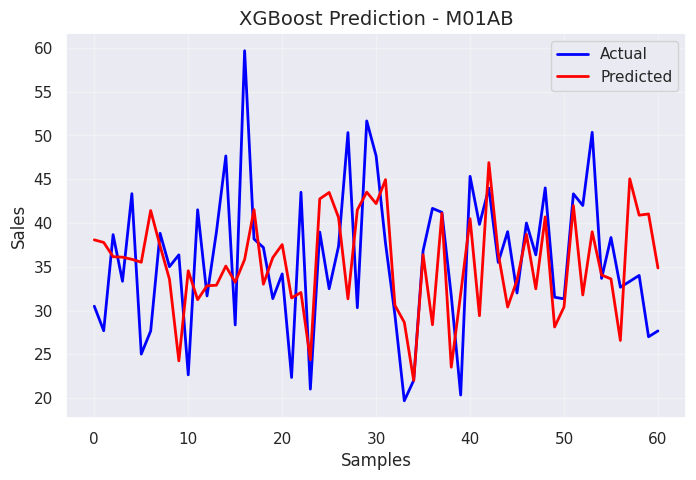

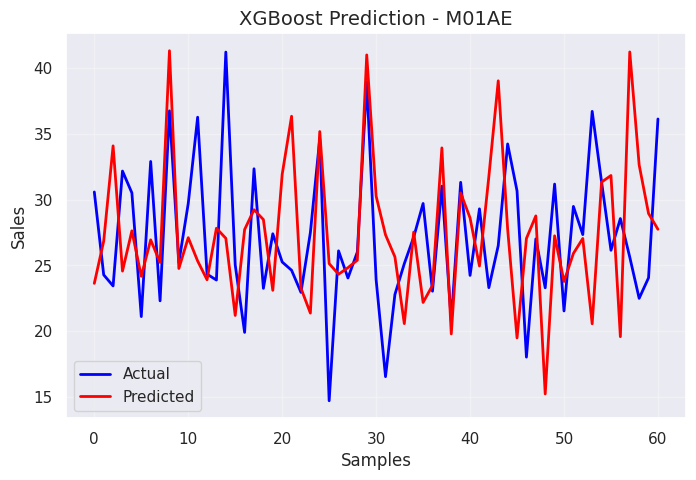

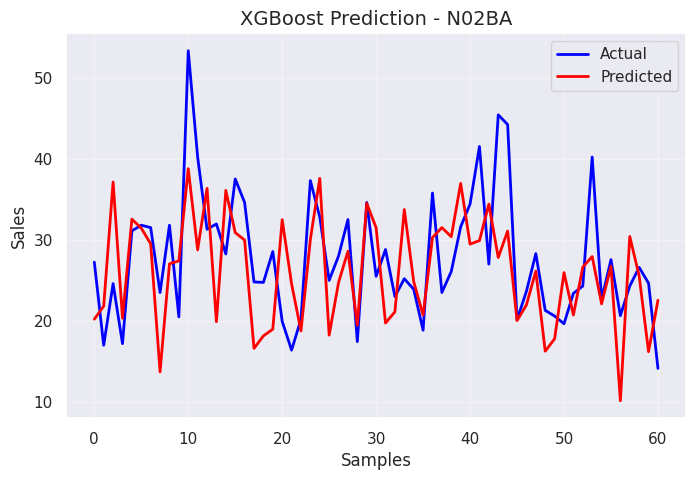

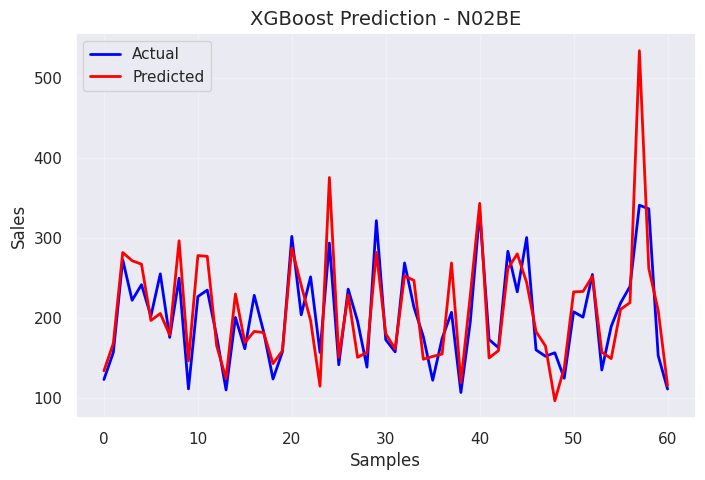

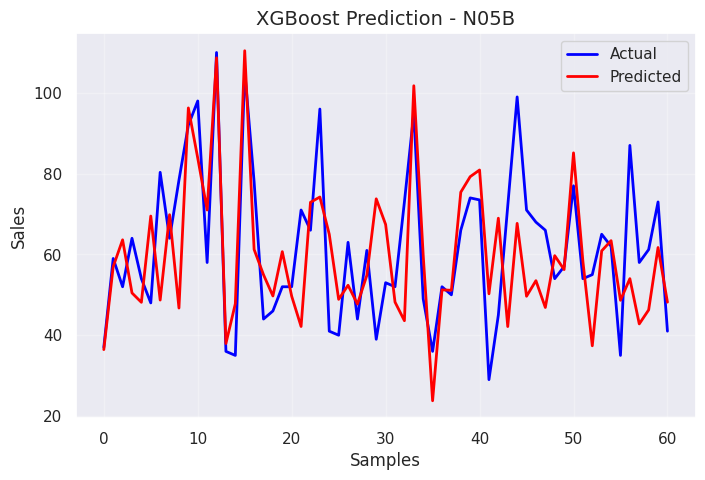

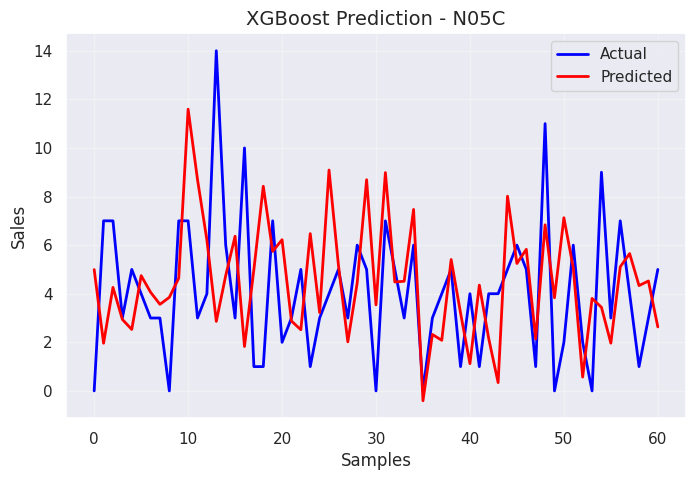

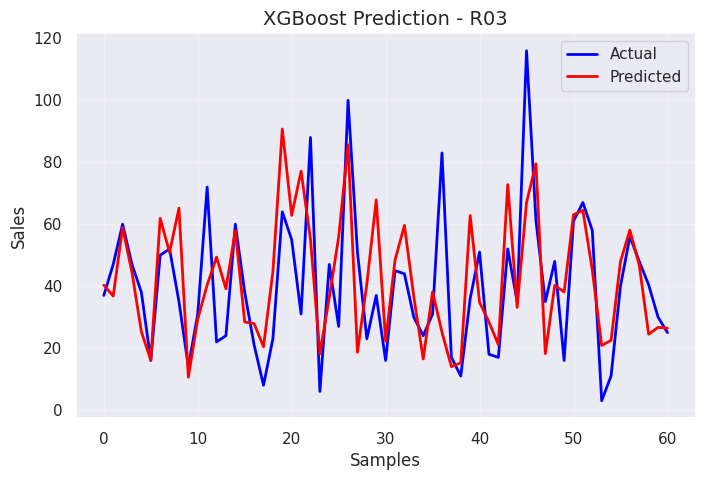

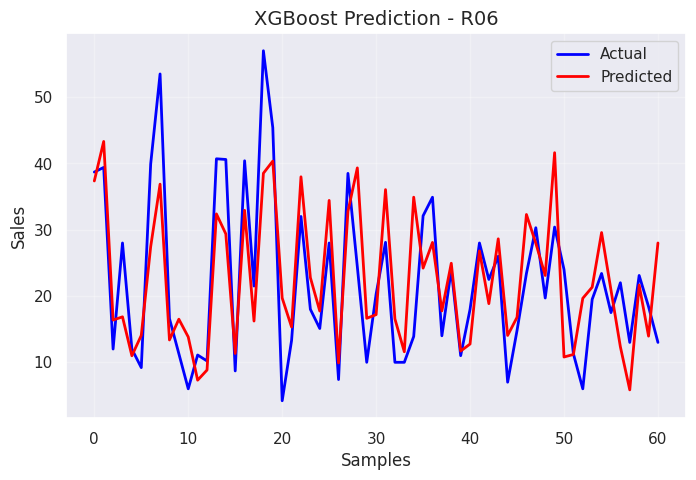

In [38]:
for target in targets:

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(
        datasets[target]['X_train'],
        datasets[target]['y_train']
    )

    pred = model.predict(datasets[target]['X_test'])

    plt.figure(figsize=(8,5))

    plt.plot(
        datasets[target]['y_test'].values,
        label='Actual',
        color='blue',
        linewidth=2
    )

    plt.plot(
        pred,
        label='Predicted',
        color='red',
        linewidth=2
    )

    plt.title(f'XGBoost Prediction - {target}', fontsize=14)

    plt.xlabel("Samples")
    plt.ylabel("Sales")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

In [39]:
xgb_df = pd.DataFrame(
    xgb_results,
    columns=[
        'Target',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

xgb_df

,Target,MAE,RMSE,R2 Score
0,M01AB,6.699719,8.326879,-0.026802
1,M01AE,5.393680,6.785627,-0.587104
2,N02BA,6.011868,7.242065,0.125693
3,N02BE,29.780035,41.435608,0.541090
4,N05B,12.539241,15.771847,0.297719
5,N05C,2.717658,3.458600,-0.505760
6,R03,13.934717,18.813588,0.308157
7,R06,6.340413,7.950510,0.575586


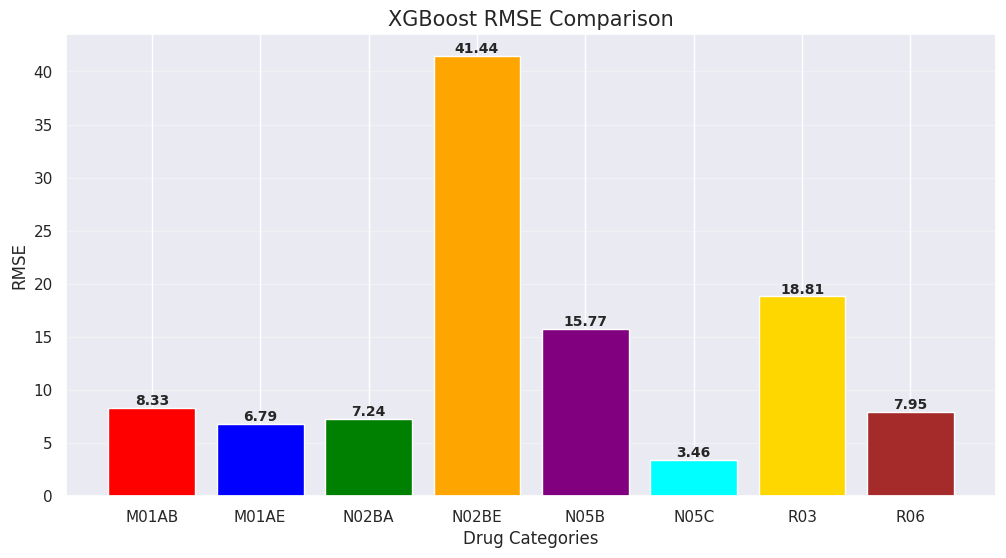

In [40]:
plt.figure(figsize=(12,6))

colors = [
    'red',
    'blue',
    'green',
    'orange',
    'purple',
    'cyan',
    'gold',
    'brown'
]

bars = plt.bar(
    xgb_df['Target'],
    xgb_df['RMSE'],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("XGBoost RMSE Comparison", fontsize=15)

plt.xlabel("Drug Categories")

plt.ylabel("RMSE")

plt.grid(axis='y', alpha=0.3)

plt.show()

# Over All Comperison 

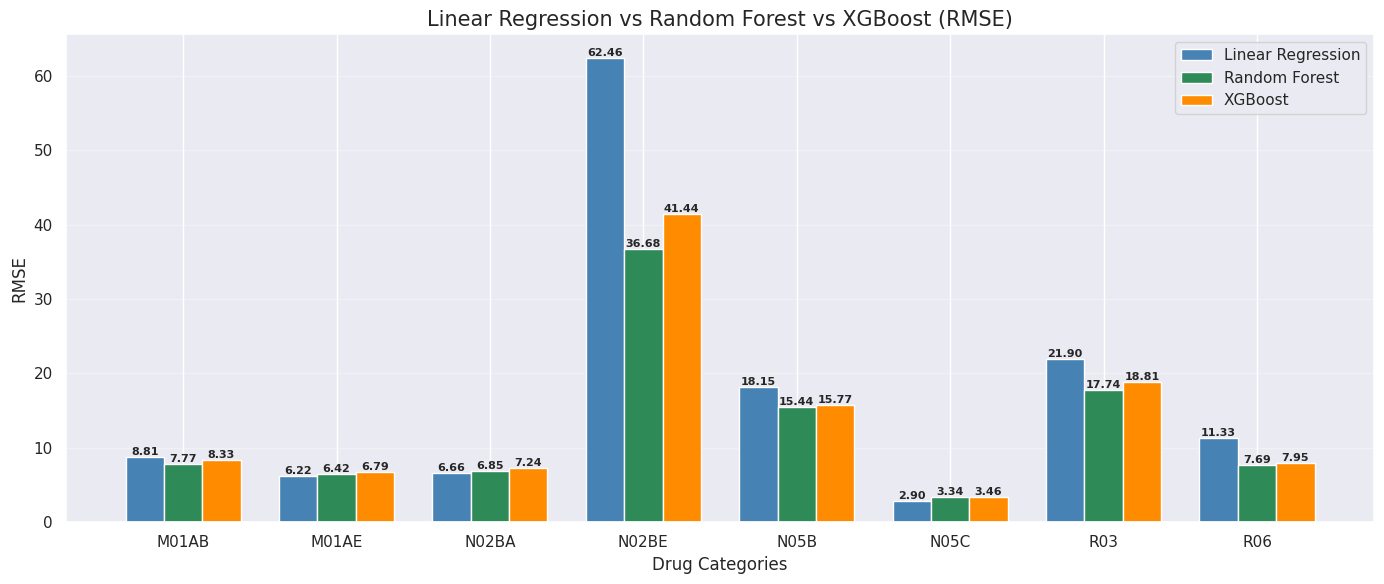

In [41]:
import matplotlib.pyplot as plt
import numpy as np

targets = lr_df['Target']

x = np.arange(len(targets))
width = 0.25

plt.figure(figsize=(14,6))

bars1 = plt.bar(
    x-width,
    lr_df['RMSE'],
    width,
    label='Linear Regression',
    color='steelblue'
)

bars2 = plt.bar(
    x,
    rf_df['RMSE'],
    width,
    label='Random Forest',
    color='seagreen'
)

bars3 = plt.bar(
    x+width,
    xgb_df['RMSE'],
    width,
    label='XGBoost',
    color='darkorange'
)

def add_value(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x()+bar.get_width()/2,
            h,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

add_value(bars1)
add_value(bars2)
add_value(bars3)

plt.xticks(x, targets)

plt.xlabel("Drug Categories", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

plt.title("Linear Regression vs Random Forest vs XGBoost (RMSE)", fontsize=15)

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

# Work Summary 

In this project, we first loaded the pharmaceutical weekly sales dataset and performed data preprocessing to prepare it for machine learning. The date column was converted into datetime format, and useful features such as Year, Month, Week, and Quarter were extracted. Missing values were checked and handled, and the data was scaled using StandardScaler. We then conducted Exploratory Data Analysis (EDA) by creating different visualizations, including sales trend graphs, correlation heatmaps, bar charts, boxplots, histograms, and monthly sales trend plots to better understand the dataset. After preprocessing, the dataset was divided into training and testing sets using an 80:20 ratio. Three machine learning regression models, namely Linear Regression, Random Forest Regressor, and XGBoost Regressor, were trained separately for eight pharmaceutical product categories (M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, and R06). The performance of each model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Actual and predicted sales values were also visualized using line graphs to assess prediction quality. Finally, the performance of the three models was compared using grouped bar charts, allowing us to identify the best-performing model for pharmaceutical sales forecasting.